# **NAMA DATASET**

**Airline Passenger Satisfaction**: https://www.kaggle.com/datasets/teejmahal20/airline-passenger-satisfaction

# **Import Library**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

# **Business Understanding**

## **Business Objective**

Tujuan utama dari analisis ini adalah untuk mengidentifikasi serta menganalisis faktor-faktor yang mempengaruhi tingkat kepuasan penumpang maskapai penerbangan. Dengan memahami faktor-faktor tersebut, diharapkan pihak maskapai dapat meningkatkan kualitas layanan serta mempertahankan loyalitas pelanggan.

## **Assess Situation**

Dalam industri penerbangan, kepuasan pelanggan merupakan indikator penting yang berpengaruh langsung terhadap keberlangsungan bisnis. Pelanggan yang puas cenderung melakukan pembelian ulang dan memberikan ulasan positif, sedangkan pelanggan yang tidak puas berpotensi beralih ke kompetitor.

Berdasarkan kondisi tersebut, diperlukan analisis berbasis data untuk mengetahui aspek layanan mana yang paling berpengaruh terhadap kepuasan pelanggan, seperti kualitas layanan di dalam pesawat, ketepatan waktu, serta kenyamanan fasilitas.

## **Analytic Goals**

Adapun tujuan analitis dari penelitian ini adalah:

- Mengidentifikasi variabel yang memiliki pengaruh signifikan terhadap kepuasan pelanggan
- Menganalisis pola hubungan antara layanan maskapai dan tingkat kepuasan
- Memberikan insight berbasis data sebagai dasar pengambilan keputusan

# **Project Plan**

Tahapan analisis yang dilakukan meliputi:

1. Memuat dataset
2. Melakukan data understanding
3. Melakukan eksplorasi data (EDA)
4. Melakukan verifikasi kualitas data
5. Melakukan data preparation


# **Data Understanding**

## **Memuat Dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/train.csv')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


## **Deskripsi Data**

Dataset yang digunakan merupakan Airline Passenger Satisfaction Dataset yang berisi informasi terkait karakteristik penumpang serta penilaian mereka terhadap berbagai aspek layanan maskapai.

Dataset ini terdiri dari **103.904 baris data** dan **25 atribut** yang mencakup variabel numerik dan kategorikal.

### **Informasi Dasar**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  object 
 3   Customer Type                      103904 non-null  object 
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  object 
 6   Class                              103904 non-null  object 
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      1039

Berdasarkan hasil eksplorasi awal:

- Terdapat **19 atribut numerik**, **5 atribut kategorikal**, dan **1 atribut target (satisfaction)**
- Tidak ditemukan missing values pada sebagian besar kolom, kecuali pada kolom Arrival Delay in Minutes
- Data telah memiliki struktur yang jelas dan siap untuk dianalisis lebih lanjut

### **Informasi Lanjutan**

In [ ]:
df.shape

(103904, 25)

In [ ]:
df.columns

Index(['Unnamed: 0', 'id', 'Gender', 'Customer Type', 'Age', 'Type of Travel',
       'Class', 'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'satisfaction'],
      dtype='object')

### **Informasi Statistik Deskriptif**

In [ ]:
df.describe()

,Unnamed: 0,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103594.000000
mean,51951.500000,64924.210502,39.379706,1189.448375,2.729683,3.060296,2.756901,2.976883,3.202129,3.250375,3.439396,3.358158,3.382363,3.351055,3.631833,3.304290,3.640428,3.286351,14.815618,15.178678
std,29994.645522,37463.812252,15.114964,997.147281,1.327829,1.525075,1.398929,1.277621,1.329533,1.349509,1.319088,1.332991,1.288354,1.315605,1.180903,1.265396,1.175663,1.312273,38.230901,38.698682
min,0.000000,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25975.750000,32533.750000,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,51951.500000,64856.500000,40.000000,843.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,77927.250000,97368.250000,51.000000,1743.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,103903.000000,129880.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


Berdasarkan statistik deskriptif:

- Variabel seperti Flight Distance dan Delay memiliki rentang nilai yang cukup besar
- Beberapa variabel layanan memiliki skala penilaian yang seragam
- Terdapat indikasi keberadaan outliers pada beberapa variabel numerik

# **Eksplorasi Data (EDA)**

## **Comparison/Perbandingan**

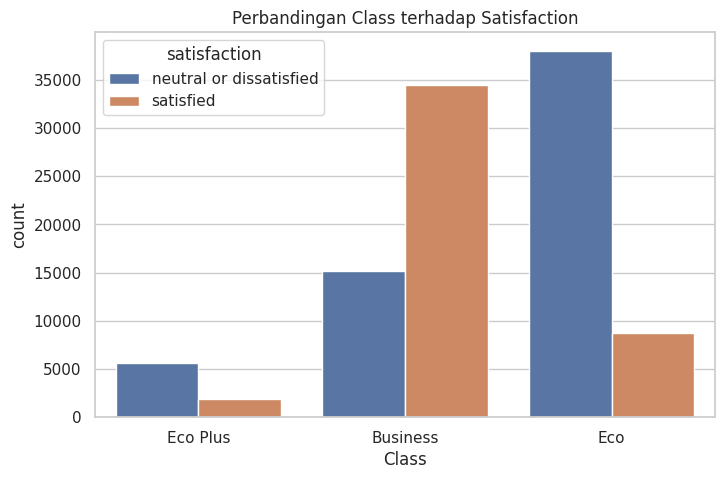

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='Class', hue='satisfaction', data=df)
plt.title('Perbandingan Class terhadap Satisfaction')
plt.show()

Berdasarkan visualisasi perbandingan antara kelas penerbangan *(Class)* dan tingkat kepuasan *(satisfaction)*, terlihat bahwa penumpang pada kelas **Business** memiliki proporsi kepuasan yang jauh lebih tinggi dibandingkan kelas **Eco** dan **Eco Plus**. Sebaliknya, penumpang pada kelas **Eco** menunjukkan dominasi pada kategori neutral or dissatisfied.

Hal ini mengindikasikan bahwa perbedaan fasilitas, kenyamanan, serta kualitas layanan antar kelas penerbangan memiliki pengaruh terhadap persepsi kepuasan pelanggan.

**Insight:**
Semakin tinggi kelas layanan yang digunakan oleh penumpang, maka semakin besar kemungkinan pelanggan merasa puas. Hal ini menunjukkan bahwa kualitas layanan premium berperan penting dalam meningkatkan kepuasan pelanggan.

## **Composition/Komposisi**

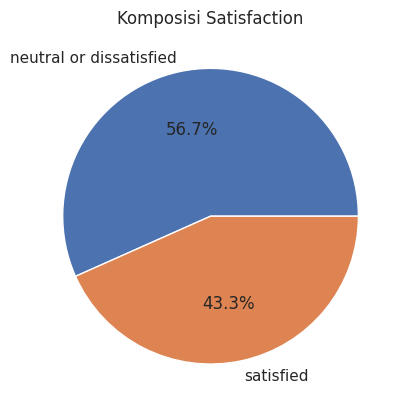

In [ ]:
df['satisfaction'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Komposisi Satisfaction')
plt.ylabel('')
plt.show()

Berdasarkan diagram pie yang ditampilkan, diketahui bahwa mayoritas penumpang berada pada kategori **neutral or dissatisfied**, dengan proporsi yang lebih besar dibandingkan kategori **satisfied**.

Kondisi ini menunjukkan bahwa secara keseluruhan, tingkat kepuasan pelanggan terhadap layanan maskapai masih belum optimal dan memerlukan perhatian lebih lanjut.

**Insight:**
Maskapai perlu melakukan evaluasi terhadap berbagai aspek layanan karena sebagian besar pelanggan belum mencapai tingkat kepuasan yang diharapkan.

## **Distribution/Distribusi**

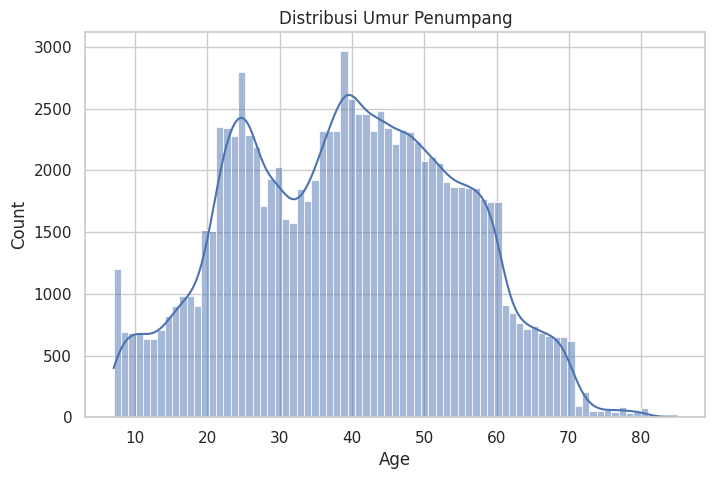

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], kde=True)
plt.title('Distribusi Umur Penumpang')
plt.show()

Distribusi usia (Age) menunjukkan bahwa mayoritas penumpang berada pada rentang usia **20 hingga 50 tahun**, yang merupakan kelompok usia produktif dan aktif melakukan perjalanan.

Distribusi ini cenderung membentuk pola normal (mendekati distribusi normal), yang menunjukkan bahwa data cukup representatif untuk dianalisis.

**Insight:**
Kelompok usia produktif umumnya memiliki ekspektasi layanan yang lebih tinggi, terutama terkait kenyamanan, efisiensi waktu, dan kemudahan akses layanan digital.

## **Relationship/Hubungan**

**a. Korelasi Antar Variabel**

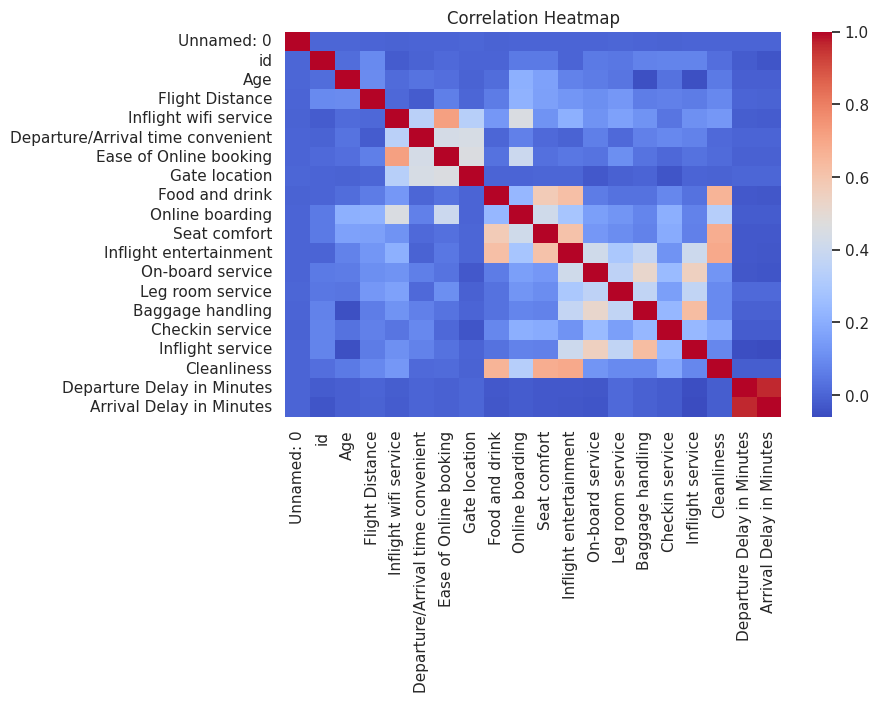

In [ ]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Berdasarkan heatmap korelasi, terlihat bahwa beberapa variabel layanan seperti:

- Seat comfort
- Inflight entertainment
- Online boarding
- On-board service

memiliki hubungan yang cukup kuat dengan variabel lainnya, yang mengindikasikan adanya keterkaitan antar aspek pelayanan dalam membentuk pengalaman pelanggan.

Meskipun tidak semua variabel menunjukkan korelasi yang sangat tinggi, pola ini tetap memberikan indikasi bahwa kualitas layanan secara keseluruhan saling berkaitan dalam mempengaruhi kepuasan pelanggan.

**Insight:**
Pengalaman pelanggan bersifat multidimensional, di mana kombinasi berbagai layanan memiliki kontribusi terhadap kepuasan, bukan hanya satu faktor tunggal.

**b. Hubungan Delay terhadap Satisfaction**

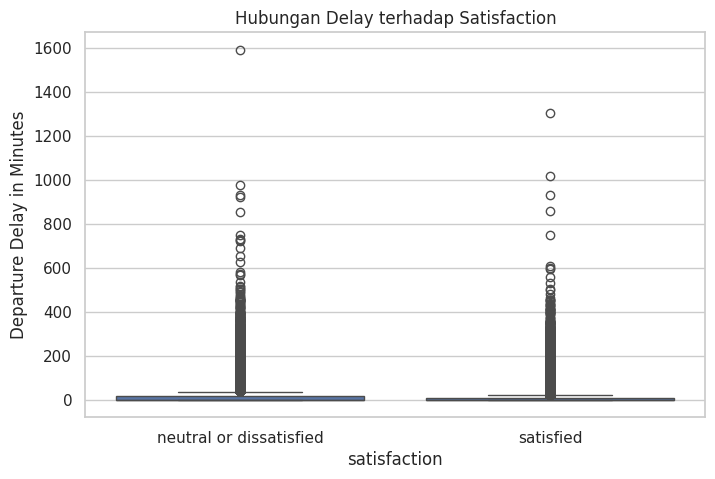

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='satisfaction', y='Departure Delay in Minutes', data=df)
plt.title('Hubungan Delay terhadap Satisfaction')
plt.show()

Berdasarkan boxplot antara Departure Delay in Minutes dan satisfaction, terlihat bahwa:

- Penumpang yang **tidak puas** cenderung memiliki nilai delay yang lebih tinggi
- Penumpang yang **puas** umumnya mengalami delay yang lebih rendah

Selain itu, terdapat beberapa nilai ekstrem (outliers) yang menunjukkan adanya delay sangat tinggi pada sebagian kecil data.

**Insight:**
Keterlambatan penerbangan merupakan salah satu faktor utama yang berdampak negatif terhadap kepuasan pelanggan. Semakin besar durasi keterlambatan, maka semakin tinggi potensi ketidakpuasan.

# **Verifikasi Kualitas Data**

## **Incosistent Values**

Pada tahap ini dilakukan pengecekan terhadap konsistensi data pada setiap kolom. Berdasarkan hasil pengecekan, tidak ditemukan nilai yang tidak konsisten, seluruh data telah sesuai dengan kategori masing-masing.

In [ ]:
print(df['Gender'].unique())
print(df['Customer Type'].unique())
print(df['Type of Travel'].unique())
print(df['Class'].unique())
print(df['satisfaction'].unique())

['Male' 'Female']
['Loyal Customer' 'disloyal Customer']
['Personal Travel' 'Business travel']
['Eco Plus' 'Business' 'Eco']
['neutral or dissatisfied' 'satisfied']


Diperoleh bahwa seluruh nilai berada dalam kategori yang valid dan tidak ditemukan adanya inkonsistensi data, seperti perbedaan penulisan atau kategori yang tidak sesuai.

**Insight:**
Konsistensi data yang baik menunjukkan bahwa proses pengumpulan data telah dilakukan secara terstruktur, sehingga tidak diperlukan proses standarisasi atau cleaning tambahan pada data kategorikal.

## **Missing Values**

In [ ]:
pd.DataFrame(df.isna().sum() / len(df) * 100, columns=['Null Ratio (%)'])

,Null Ratio (%)
Unnamed: 0,0.000000
id,0.000000
Gender,0.000000
Customer Type,0.000000
Age,0.000000
Type of Travel,0.000000
Class,0.000000
Flight Distance,0.000000
Inflight wifi service,0.000000
Departure/Arrival time convenient,0.000000


Berdasarkan hasil perhitungan rasio missing values, ditemukan bahwa hanya terdapat nilai kosong pada kolom **Arrival Delay in Minutes**, sementara kolom lainnya tidak memiliki missing values.

Jumlah missing values pada kolom tersebut relatif kecil dibandingkan total data (103.904 baris), sehingga tidak memberikan dampak signifikan terhadap keseluruhan distribusi data.

**Insight:**
Missing values pada variabel delay kemungkinan disebabkan oleh ketidaktercatatan waktu kedatangan pada beberapa penerbangan. Karena proporsinya kecil, penanganan menggunakan imputasi (misalnya mean) dapat dilakukan tanpa mengurangi kualitas data secara signifikan.

## **Duplicated Values**

In [ ]:
df.duplicated().sum()

np.int64(0)

Hasil pengecekan menunjukkan bahwa **jumlah data duplikat adalah 0**, yang berarti tidak terdapat baris data yang berulang dalam dataset.

**Insight:**
Tidak adanya data duplikat menunjukkan bahwa setiap baris data merepresentasikan satu entitas unik, sehingga tidak diperlukan proses penghapusan data dan tidak terdapat risiko bias akibat penggandaan data.

## **Outliers Values**

In [ ]:
results = []

cols = df.select_dtypes(include=['float64', 'int64'])

for col in cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    percent = (len(outliers) / len(df)) * 100

    results.append({'Kolom': col, 'Persentase Outliers': percent})

pd.DataFrame(results)

,Kolom,Persentase Outliers
0,Unnamed: 0,0.000000
1,id,0.000000
2,Age,0.000000
3,Flight Distance,2.204920
4,Inflight wifi service,0.000000
5,Departure/Arrival time convenient,0.000000
6,Ease of Online booking,0.000000
7,Gate location,0.000000
8,Food and drink,0.000000
9,Online boarding,0.000000


Hasil identifikasi menunjukkan bahwa terdapat outliers pada beberapa variabel numerik, terutama pada:

- Departure Delay in Minutes
- Arrival Delay in Minutes
- Flight Distance

Outliers ini ditunjukkan oleh adanya nilai yang berada di luar batas bawah dan batas atas yang ditentukan oleh metode IQR.

**Insight:**
Keberadaan outliers, khususnya pada variabel delay, mencerminkan adanya kejadian ekstrem seperti keterlambatan penerbangan yang sangat tinggi. Jika tidak ditangani, outliers dapat mempengaruhi hasil analisis statistik, terutama nilai rata-rata (mean), sehingga perlu dilakukan penanganan pada tahap data preparation.

# **Data Preparation**

## **Incosistent Values**

Berdasarkan hasil verifikasi sebelumnya, tidak ditemukan nilai yang tidak konsisten sehingga tidak dilakukan penanganan lebih lanjut.

## **Missing Values**

In [ ]:
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(df['Arrival Delay in Minutes'].mean())

In [ ]:
df['Arrival Delay in Minutes'].isna().sum()

np.int64(0)

Missing values pada kolom Arrival Delay in Minutes ditangani menggunakan metode mean imputation, yaitu mengganti nilai kosong dengan rata-rata dari kolom tersebut.

Metode ini dipilih karena:

- Jumlah missing relatif kecil
- Tidak ingin mengurangi jumlah data (dibandingkan drop)
- Distribusi data tetap terjaga

**Insight:**
Pendekatan ini memastikan bahwa data tetap lengkap tanpa menghilangkan informasi penting.

## **Duplicated Values**

Tidak dilakukan penanganan karena tidak ditemukan data duplikat.

## **Outliers Values**

In [ ]:
for col in df.select_dtypes(include=['float64', 'int64']):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower, lower,
                       np.where(df[col] > upper, upper, df[col]))

In [ ]:
df.describe()

,Unnamed: 0,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000
mean,51951.500000,64924.210502,39.379706,1186.133927,2.729683,3.060296,2.756901,2.976883,3.202129,3.250375,3.439396,3.358158,3.382363,3.351055,3.631833,3.366333,3.640428,3.286351,7.396299,7.954779
std,29994.645522,37463.812252,15.114964,988.126724,1.327829,1.525075,1.398929,1.277621,1.329533,1.349509,1.319088,1.332991,1.288354,1.315605,1.180903,1.158642,1.175663,1.312273,11.223866,11.964269
min,0.000000,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.500000,0.000000,0.000000,0.000000,0.000000
25%,25975.750000,32533.750000,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,51951.500000,64856.500000,40.000000,843.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,77927.250000,97368.250000,51.000000,1743.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,103903.000000,129880.000000,85.000000,3736.500000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,30.000000,32.500000


Outliers ditangani menggunakan metode **IQR dengan teknik capping**, yaitu membatasi nilai ekstrem ke batas minimum dan maksimum yang diperbolehkan.

Alasan pemilihan metode:

- Tidak menghapus data (menghindari kehilangan informasi)
- Menjaga distribusi data tetap stabil
- Mengurangi pengaruh nilai ekstrem terhadap analisis

**Insight:**
Penanganan ini sangat penting terutama pada variabel delay, karena nilai ekstrem dapat menyebabkan bias dalam interpretasi hasil analisis.

# **Construct Data**

In [ ]:
df['Delay Category'] = df['Departure Delay in Minutes'].apply(lambda x: 'Late' if x > 15 else 'On Time')

In [ ]:
df['Delay Category'].value_counts()

,count
Delay Category,
On Time,80852
Late,23052


Variabel baru **Delay Category** dibuat untuk mengelompokkan keterlambatan menjadi dua kategori:

- On Time (≤ 15 menit)
- Late (> 15 menit)

Pengelompokan ini bertujuan untuk:

- Mempermudah analisis kategorikal
- Mengidentifikasi pengaruh keterlambatan secara lebih jelas terhadap kepuasan

**Insight:**
Fitur baru ini memberikan sudut pandang tambahan dalam memahami bagaimana keterlambatan mempengaruhi pengalaman pelanggan.

# **Data Reduction**

In [ ]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [ ]:
df.columns

Index(['id', 'Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class',
       'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'satisfaction', 'Delay Category'],
      dtype='object')

Kolom **Unnamed: 0** dihapus karena tidak memiliki makna analitis (hanya indeks).

**Insight:**
Penghapusan atribut yang tidak relevan membantu menyederhanakan dataset dan meningkatkan efisiensi analisis.

**Validasi Hasil Data Preparation**

Setelah seluruh proses data preparation dilakukan, dilakukan validasi untuk memastikan kualitas dataset.

Hasil validasi menunjukkan bahwa:

- Tidak terdapat missing values
- Tidak terdapat data duplikat
- Nilai outliers telah dikendalikan
- Dataset memiliki fitur tambahan (Delay Category)
- Struktur data menjadi lebih bersih dan konsisten

**Insight Akhir:**
Dataset yang telah melalui proses data preparation memiliki kualitas yang lebih baik, sehingga mampu menghasilkan analisis yang lebih akurat, reliabel, dan dapat digunakan sebagai dasar pengambilan keputusan yang lebih tepat.

# **Kesimpulan**

Berdasarkan keseluruhan proses analisis yang telah dilakukan, dapat disimpulkan bahwa tingkat kepuasan penumpang maskapai dipengaruhi oleh berbagai faktor yang bersifat multidimensional.

Faktor-faktor utama yang berpengaruh meliputi:

- Kualitas layanan dalam penerbangan (seperti seat comfort, inflight entertainment, dan service)
- Kelas penerbangan (Class)
- Ketepatan waktu penerbangan (delay)

Selain itu, hasil analisis menunjukkan bahwa pelanggan pada kelas layanan yang lebih tinggi cenderung memiliki tingkat kepuasan yang lebih tinggi, serta keterlambatan penerbangan memiliki dampak signifikan terhadap ketidakpuasan pelanggan.

Dengan demikian, peningkatan kualitas layanan secara menyeluruh serta pengelolaan ketepatan waktu penerbangan menjadi aspek kunci dalam meningkatkan kepuasan pelanggan.